In [16]:
from __future__ import annotations

import os
import sys
import pickle
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

# Repo root setup
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.data.pkl_dataset import PKLEnergyForceDataset, PKLKeys

In [17]:
# --- Configuration ---
# Path to the directory containing .pkl files
# DATASET_DIR = Path("/home/iwe67/qm9_dataset_EBDM/qm9_pkl")
DATASET_DIR = Path("/home/iwe67/qm9_dataset_EBDM/test")

# Keys expected inside the pickle files (adjust if your dataset uses different keys)
KEYS = PKLKeys(
    pos="pos",
    atom_types="atomic_numbers",
    energy="e_total",
    forces="forces"
)

# Limit number of files to scan (set to None for full dataset)
FILE_LIMIT = None 

In [18]:
# Load dataset metadata (without loading full tensors into memory yet)
# We use the class to find files, but we might iterate manually for speed/custom stats.

if not DATASET_DIR.exists():
    print(f"Warning: Dataset directory {DATASET_DIR} does not exist. Please check the path.")
else:
    # We can use the dataset class to get the file list
    # We don't necessarily need the strict atomic number mapping unless we use the __getitem__ exactly as training does.
    dataset = PKLEnergyForceDataset(
        data_dir=DATASET_DIR,
        keys=KEYS,
        atom_types_format="atomic_numbers",
        file_limit=FILE_LIMIT,
        allowed_atomic_numbers=None, # Let it infer or we ignore invalid ones during manual scan
    )
    
    print(f"Found {len(dataset)} files in {DATASET_DIR}")

Found 1 files in /home/iwe67/qm9_dataset_EBDM/test


In [19]:
# --- Collect Statistics ---

energies = []
num_atoms = []
all_atomic_numbers = []

print("Scanning dataset...")

# We iterate manually to handle potential missing keys gracefully or collecting raw values
for i in tqdm(range(len(dataset))):
    fp = dataset.file_paths[i]
    try:
        with open(fp, "rb") as f:
            data = pickle.load(f)
            
        # 1. Energy
        # Handle 0-d array, 1-d array, or scalar
        if KEYS.energy in data:
            e = data[KEYS.energy]
            if hasattr(e, 'item'): e = e.item()
            elif hasattr(e, '__len__') and len(e) == 1: e = float(e[0])
            energies.append(float(e))
            
        # 2. Number of atoms & types
        # Assuming pos is (N, 3)
        if KEYS.pos in data:
            pos = data[KEYS.pos]
            n = pos.shape[0] if hasattr(pos, 'shape') else len(pos)
            num_atoms.append(n)
            
        if KEYS.atom_types in data:
            z = data[KEYS.atom_types]
            if hasattr(z, 'tolist'): z = z.tolist()
            all_atomic_numbers.extend(z)
            
    except Exception as e:
        print(f"Error reading {fp.name}: {e}")

energies = np.array(energies)
num_atoms = np.array(num_atoms)
atom_counts = Counter(all_atomic_numbers)

print(f"\nScanned {len(energies)} items successfully.")
print(f"Energy Mean: {np.mean(energies):.4f} +/- {np.std(energies):.4f}")
print(f"Molecule Size Mean: {np.mean(num_atoms):.2f} +/- {np.std(num_atoms):.2f}")

Scanning dataset...


100%|██████████| 1/1 [00:00<00:00, 4240.95it/s]


Scanned 1 items successfully.
Energy Mean: -384.5470 +/- 0.0000
Molecule Size Mean: 17.00 +/- 0.00


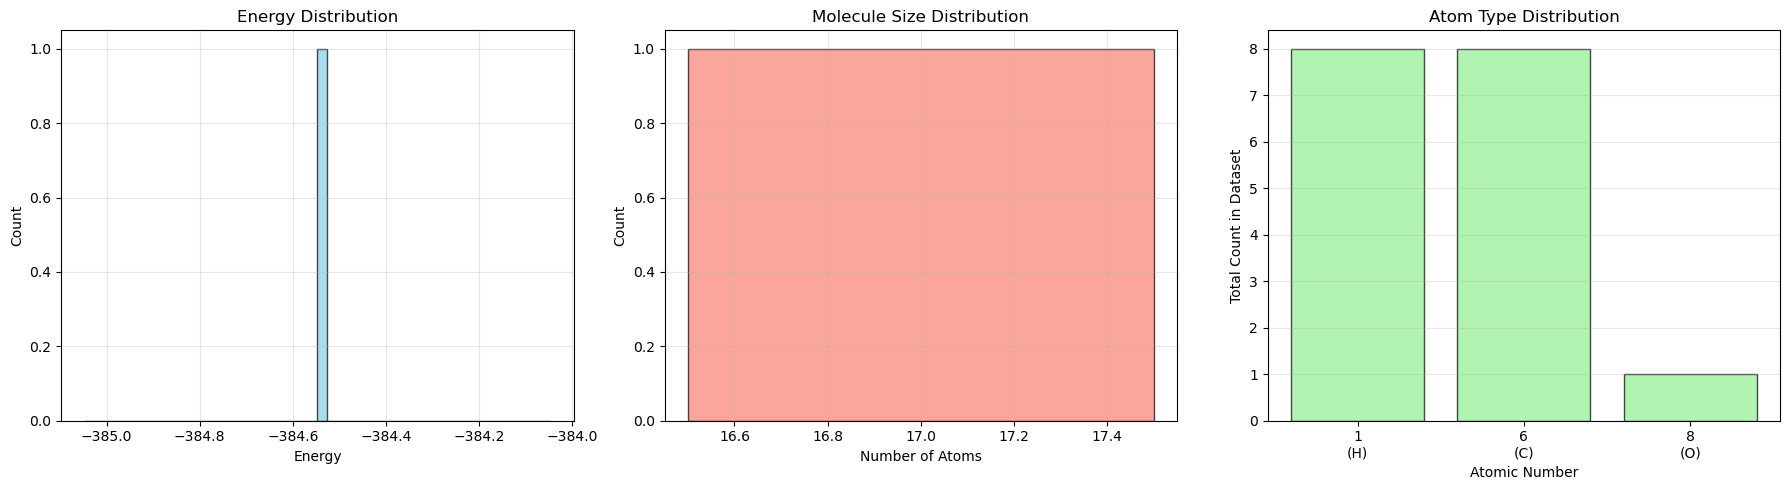

In [20]:
# --- Plotting ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Energy Histogram
axes[0].hist(energies, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Energy Distribution')
axes[0].set_xlabel('Energy')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# 2. Molecule Size Histogram
axes[1].hist(num_atoms, bins=range(min(num_atoms), max(num_atoms) + 2), color='salmon', edgecolor='black', alpha=0.7, align='left')
axes[1].set_title('Molecule Size Distribution')
axes[1].set_xlabel('Number of Atoms')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

# 3. Atom Types Bar Chart
# Sort by atomic number
zs = sorted(atom_counts.keys())
counts = [atom_counts[z] for z in zs]
# Label with element symbol if possible
from rdkit import Chem
try:
    pt = Chem.GetPeriodicTable()
    labels = [f"{z}\n({pt.GetElementSymbol(int(z))})" for z in zs]
except:
    labels = [str(z) for z in zs]

axes[2].bar(labels, counts, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].set_title('Atom Type Distribution')
axes[2].set_xlabel('Atomic Number')
axes[2].set_ylabel('Total Count in Dataset')
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()